In [1]:
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca
print("All imports OK")
print(f"CasADi version: {ca.__version__}")


All imports OK
CasADi version: 3.7.2


# 01 — Open-Loop Simulation: Double Integrator

This notebook simulates a **double integrator** in open loop using pure NumPy.

No classes, no CasADi, no abstractions. Everything is explicit and flat.

**System:**
The double integrator models a mass driven by a force input:
- State: x = [position, velocity]
- Input: u = [force/acceleration]

**Goal:** Run the full pipeline end-to-end:
Docker → JupyterLab → notebook → simulation → plot


In [2]:
## 1. Imports


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_discrete_are



## Functions to input

In [4]:
def state_controller(x, xd):
    K  = np.array([[2.0, 3.0]])
    return -K @ (x - xd)


In [ ]:

def lqr_controller(x, xd):
    Q = np.diag([10.0, 1.0])  # state cost: penalize position more
    R = np.array([[1.0]])      # input cost

    P = solve_discrete_are(A, B, Q, R)
    K = np.linalg.inv(R + B.T @ P @ B) @ (B.T @ P @ A)

    return -K @ (x - xd)


## 2. System Definition

Discrete-time state-space model:

$$x_{k+1} = A x_k + B u_k$$

For a double integrator with sampling time $\Delta t$:

$$A = \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix}, \quad B = \begin{bmatrix} \frac{\Delta t^2}{2} \\ \Delta t \end{bmatrix}$$

Wait — for a simple Euler-discretized single-input double integrator:

$$A = \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix}, \quad B = \begin{bmatrix} 0 \\ \Delta t \end{bmatrix}$$


In [5]:
dt = 0.1  # sampling time [s]

A = np.array([[1, dt],
              [0,  1]])

B = np.array([[0  ],
              [dt ]])

nx = 2   # number of states
nu = 1   # number of inputs

print("A =", A)
print("B =", B)


A = [[1.  0.1]
 [0.  1. ]]
B = [[0. ]
 [0.1]]


## 3. Simulation Setup

Define the initial condition, input sequence, and simulation horizon.


In [6]:
nSteps  = 50          # number of simulation steps
x0 = np.array([1.0, 0.0])   # initial state: position=0, velocity=1

# Constant zero input (open loop — no control action)
U = np.zeros((nSteps, nu))

# Storage
X = np.zeros((nSteps + 1, nx))
X[0] = x0


In [7]:
# Storage
Xd = np.zeros((nSteps + 1, nx))

## 4. Simulation Loop

Manually propagate the state forward using the state-space equation.


In [8]:
for k in range(nSteps):
    U[k] = state_controller(X[k], Xd[k])
    X[k+1] = A @ X[k] + B @ U[k]


## 5. Results


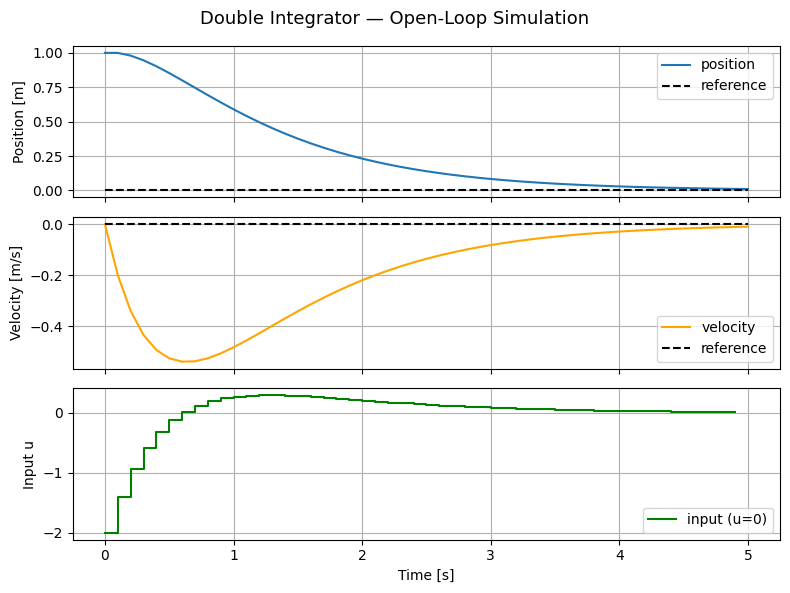

In [9]:
t = np.arange(nSteps + 1) * dt

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

axes[0].plot(t, X[:, 0], label='position')
axes[0].plot(t, Xd[:, 0], 'k--', label='reference')
axes[0].set_ylabel('Position [m]')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(t, X[:, 1], label='velocity', color='orange')
axes[1].plot(t, Xd[:, 1], 'k--', label='reference')
axes[1].set_ylabel('Velocity [m/s]')
axes[1].grid(True)
axes[1].legend()

axes[2].step(t[:-1], U[:, 0], label='input (u=0)', color='green', where='post')
axes[2].set_ylabel('Input u')
axes[2].set_xlabel('Time [s]')
axes[2].grid(True)
axes[2].legend()

plt.suptitle('Double Integrator — Open-Loop Simulation', fontsize=13)
plt.tight_layout()
plt.show()
